In [3]:
import pandas as pd

df = pd.read_csv("StudentPerformanceFactors.csv")

df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


In [5]:
def descriptive_statistics(sample, column):
    mean_value = sample[column].mean()
    median_value = sample[column].median()
    mode_value = sample[column].mode()[0]
    variance_value = sample[column].var()
    std_value = sample[column].std()
    min_value = sample[column].min()
    max_value = sample[column].max()
    q1_value = sample[column].quantile(0.25)
    q3_value = sample[column].quantile(0.75)

    print("Descriptive Statistics for:", column)
    print("Mean:", mean_value)
    print("Median:", median_value)
    print("Mode:", mode_value)
    print("Variance:", variance_value)
    print("Standard Deviation:", std_value)
    print("Minimum:", min_value)
    print("Maximum:", max_value)
    print("Q1:", q1_value)
    print("Q3:", q3_value)

In [6]:
descriptive_statistics(df, "Exam_Score")

Descriptive Statistics for: Exam_Score
Mean: 67.23565914938702
Median: 67.0
Mode: 68
Variance: 15.135646185952773
Standard Deviation: 3.890455781261724
Minimum: 55
Maximum: 101
Q1: 65.0
Q3: 69.0


In [7]:
random_sample = df.sample(n=150, random_state=1)
descriptive_statistics(random_sample, "Exam_Score")

Descriptive Statistics for: Exam_Score
Mean: 67.74
Median: 67.0
Mode: 68
Variance: 18.811140939597287
Standard Deviation: 4.337181220516072
Minimum: 58
Maximum: 95
Q1: 65.0
Q3: 69.75


In [8]:
step = len(df) // 150
systematic_sample = df.iloc[::step]
descriptive_statistics(systematic_sample, "Exam_Score")


Descriptive Statistics for: Exam_Score
Mean: 67.98013245033113
Median: 67.0
Mode: 66
Variance: 22.086269315673306
Standard Deviation: 4.699603101930343
Minimum: 61
Maximum: 94
Q1: 65.0
Q3: 70.0


In [9]:
df["Exam_Score"].describe()

,Exam_Score
count,6607.000000
mean,67.235659
std,3.890456
min,55.000000
25%,65.000000
50%,67.000000
75%,69.000000
max,101.000000


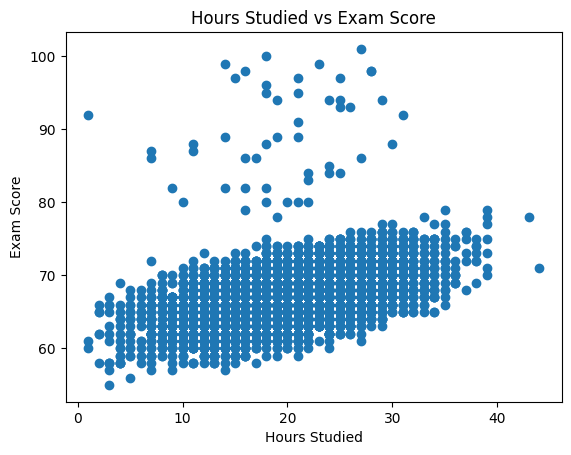

In [10]:
import matplotlib.pyplot as plt

plt.scatter(df["Hours_Studied"], df["Exam_Score"])
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs Exam Score")
plt.show()

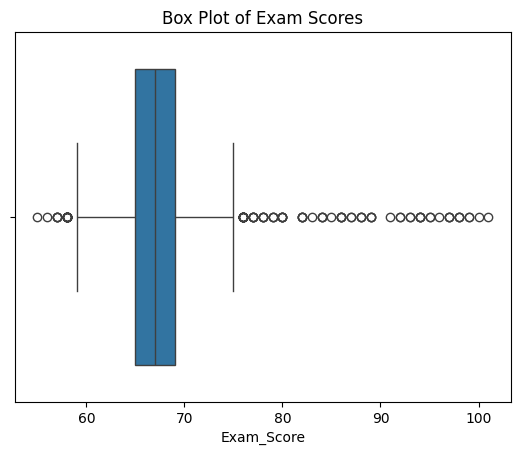

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Box plot of Exam Score
sns.boxplot(x=df["Exam_Score"])

plt.title("Box Plot of Exam Scores")

plt.show()

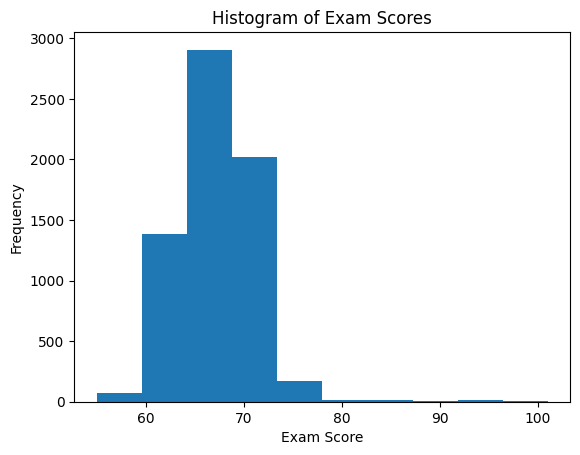

In [12]:
import matplotlib.pyplot as plt
plt.hist(df["Exam_Score"], bins=10)
plt.title("Histogram of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.show()

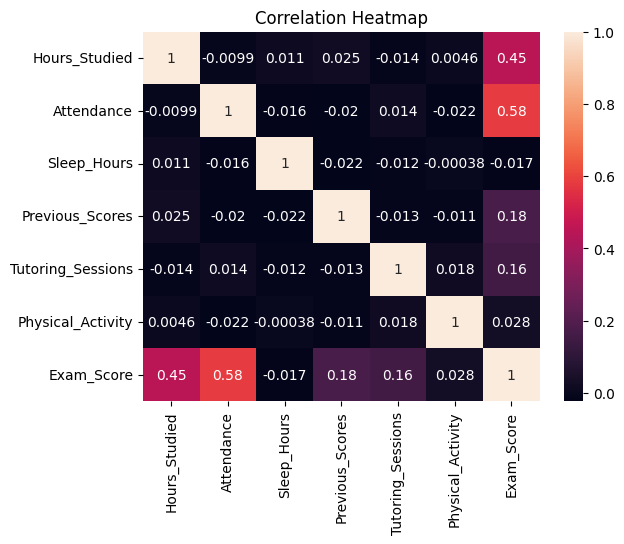

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [14]:
from scipy import stats

pearson_corr, pearson_p = stats.pearsonr(df["Hours_Studied"], df["Exam_Score"])

print("Pearson Correlation:", pearson_corr)
print("P-value:", pearson_p)

Pearson Correlation: 0.44545495407528213
P-value: 1.28635e-319


In [15]:

spearman_corr, spearman_p = stats.spearmanr(df["Hours_Studied"], df["Exam_Score"])

print("Spearman Correlation:", spearman_corr)
print("P-value:", spearman_p)

Spearman Correlation: 0.48095596242825545
P-value: 0.0


In [16]:
from scipy import stats
df["Performance_Level"] = pd.cut(
    df["Exam_Score"],
    bins=[0, 60, 75, 100],
    labels=["Low", "Medium", "High"]
)

contingency_table = pd.crosstab(df["Motivation_Level"], df["Performance_Level"])

chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-square value:", chi2)
print("P-value:", p)

Chi-square value: 18.436822308569994
P-value: 0.0010136272489815479


In [17]:
t_stat, p_value = stats.ttest_1samp(df["Exam_Score"], 70)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -57.75548850932195
P-value: 0.0
